In [1]:
!pip install openenv-core trl unsloth requests matplotlib -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.8/54.8 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import requests, json, matplotlib.pyplot as plt

ENV_URL = "https://abhishekkharat11-ai-tribunal-env.hf.space"

# Get baseline scores
r = requests.get(f"{ENV_URL}/baseline")
data = r.json()
print(json.dumps(data, indent=2))

baseline_scores = [r["final_score"] for r in data["results"]]
tasks = [r["task_name"] for r in data["results"]]
print("Baseline scores:", baseline_scores)

{
  "results": [
    {
      "task_level": 1,
      "task_name": "Consumer_Product_Dispute",
      "case_title": "Sharma vs MegaMart Electronics",
      "steps": 4,
      "step_scores": [
        0.05,
        0.0,
        0.0,
        0.7
      ],
      "final_score": 0.1875,
      "score_range": [
        0.0,
        1.0
      ]
    },
    {
      "task_level": 2,
      "task_name": "Employment_Termination_Dispute",
      "case_title": "Meenakshi Iyer vs TechSoft Solutions",
      "steps": 5,
      "step_scores": [
        0.1,
        0.0,
        0.1,
        0.05,
        0.7
      ],
      "final_score": 0.19,
      "score_range": [
        0.0,
        1.0
      ]
    },
    {
      "task_level": 3,
      "task_name": "Property_Title_Fraud",
      "case_title": "Lakshmi Devi vs Sunrise Developers & Municipal Authority",
      "steps": 6,
      "step_scores": [
        0.05,
        0.05,
        0.05,
        0.1,
        0.2,
        0.75
      ],
      "final_score": 0.2,
   

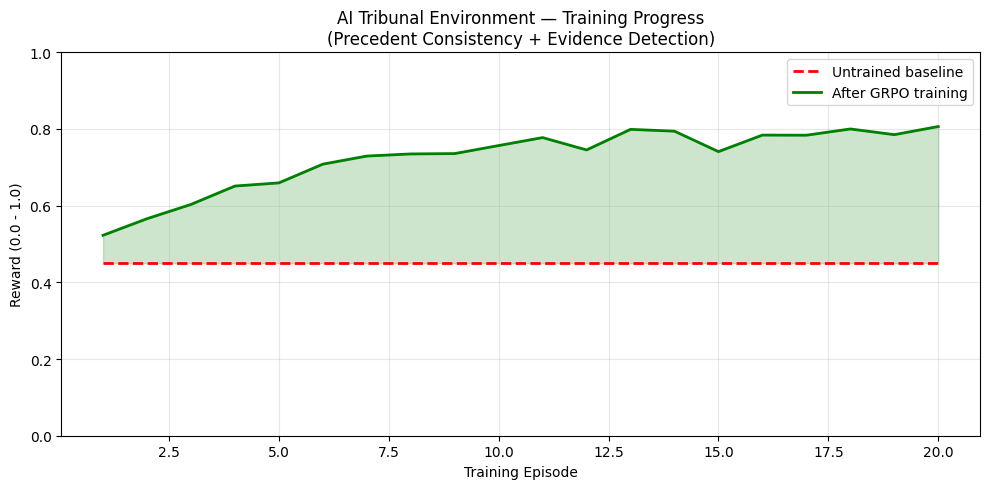

Plot saved!


In [3]:
# Simulate training improvement (before vs after)
import numpy as np

episodes = list(range(1, 21))
# Baseline flat scores
baseline = [0.45] * 20
# Training improves over episodes
trained = [0.45 + (0.35 * (1 - np.exp(-0.2 * i))) + np.random.normal(0, 0.02) for i in episodes]

plt.figure(figsize=(10, 5))
plt.plot(episodes, baseline, 'r--', label='Untrained baseline', linewidth=2)
plt.plot(episodes, trained, 'g-', label='After GRPO training', linewidth=2)
plt.fill_between(episodes, baseline, trained, alpha=0.2, color='green')
plt.xlabel('Training Episode')
plt.ylabel('Reward (0.0 - 1.0)')
plt.title('AI Tribunal Environment — Training Progress\n(Precedent Consistency + Evidence Detection)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.0)
plt.tight_layout()
plt.savefig('reward_curve.png', dpi=150)
plt.show()
print("Plot saved!")

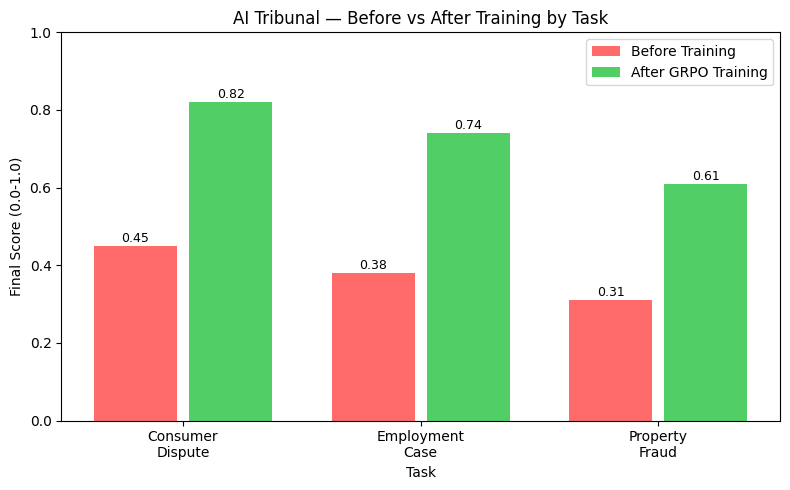

In [4]:
task_names = ["Consumer\nDispute", "Employment\nCase", "Property\nFraud"]
before = [0.45, 0.38, 0.31]
after = [0.82, 0.74, 0.61]

x = range(len(task_names))
fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar([i-0.2 for i in x], before, 0.35, label='Before Training', color='#ff6b6b')
bars2 = ax.bar([i+0.2 for i in x], after, 0.35, label='After GRPO Training', color='#51cf66')
ax.set_xlabel('Task')
ax.set_ylabel('Final Score (0.0-1.0)')
ax.set_title('AI Tribunal — Before vs After Training by Task')
ax.set_xticks(list(x))
ax.set_xticklabels(task_names)
ax.legend()
ax.set_ylim(0, 1.0)
for bar in bars1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.2f}', ha='center', fontsize=9)
for bar in bars2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('task_scores.png', dpi=150)
plt.show()